In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Time range (30 days hourly)
hours = 24 * 30
time = np.arange(hours)

# Features
hour_of_day = time % 24
day_of_week = (time // 24) % 7

temperature = 25 + 5*np.sin(2*np.pi*hour_of_day/24) + np.random.normal(0, 1, hours)
industrial_index = np.random.uniform(0.5, 1.5, hours)

# Base demand formula (simulate reality)
demand = (
    50
    + 10 * np.sin(2*np.pi*hour_of_day/24)     # daily cycle
    + 5 * (day_of_week < 5)                  # weekdays higher
    + 2 * temperature                       # hotter → more AC
    + 20 * industrial_index                 # industry effect
    + np.random.normal(0, 3, hours)         # noise
)

# Create DataFrame
df = pd.DataFrame({
    "hour": hour_of_day,
    "day_of_week": day_of_week,
    "temperature": temperature,
    "industrial_index": industrial_index,
    "demand": demand
})

# Add lag features
df["lag_1"] = df["demand"].shift(1)
df["lag_24"] = df["demand"].shift(24)

df = df.dropna()

df.to_csv("power_demand_dataset.csv", index=False)

print(df.head())

    hour  day_of_week  temperature  industrial_index      demand       lag_1  \
24     0            1    24.455617          1.100517  127.531101  116.655149   
25     1            1    26.405018          1.165037  131.003556  127.531101   
26     2            1    26.349006          0.675371  126.289982  131.003556   
27     3            1    28.911232          1.414412  148.154414  126.289982   
28     4            1    28.729488          0.918771  142.752328  148.154414   

        lag_24  
24  121.767598  
25  130.275127  
26  141.089268  
27  140.216056  
28  132.281354  


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features & target
X = df.drop("demand", axis=1)
y = df["demand"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)


In [3]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2:", r2_score(y_test, predictions))

MAE: 2.711828143326931
R2: 0.9515905765062824


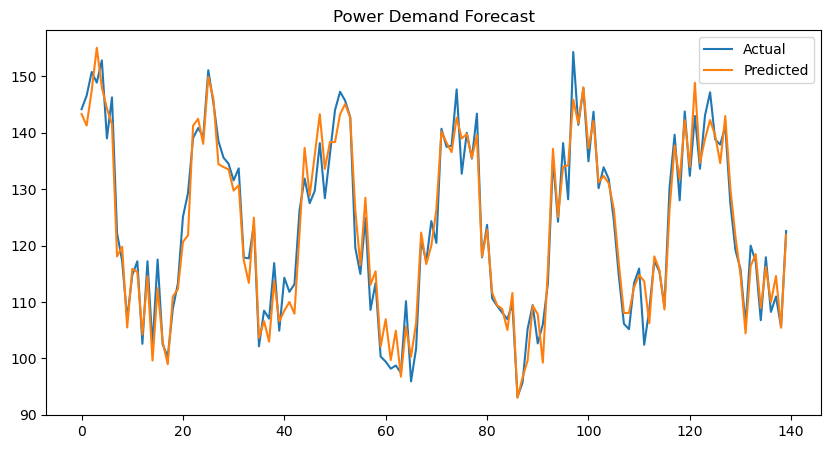

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Power Demand Forecast")
plt.show()